# LLM Repeatability Analysis

**Question**: does the LLM produce the same extraction when run multiple times on the same document?

### How to use
1. Run `genai_v3` on your `repeat_test_*.jsonl` file **N times** (3 minimum, 5 recommended)
2. Save each run's output to separate files, e.g. `run1_entities.jsonl`, `run2_entities.jsonl`…
3. Fill in the CONFIG cell below and run all cells top to bottom

### What is measured
For every document and every pair of runs:
- **Entity Jaccard** — overlap on extracted entity names
- **Entity (name, type) Jaccard** — overlap including type consistency
- **Relation triple Jaccard** — overlap on (source, relation_type, target) edges
- **Relation type Jaccard** — overlap on relation type vocabulary used
- **Cosine of type distributions** — same proportion of each type across runs
- **Off-enum rate** — relation types that escaped the locked enum

In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Add one entry per run. Files must be the JSONL outputs of genai_v3
# run on the SAME input file (your repeat_test_*.jsonl).

RUNS = [
    {"label": "Run 1", "entities": "run1_entities.jsonl", "relations": "run1_relations.jsonl"},
    {"label": "Run 2", "entities": "run2_entities.jsonl", "relations": "run2_relations.jsonl"},
    {"label": "Run 3", "entities": "run3_entities.jsonl", "relations": "run3_relations.jsonl"},
    # Add more runs here if needed:
    # {"label": "Run 4", "entities": "run4_entities.jsonl", "relations": "run4_relations.jsonl"},
]

# Canonical relation types — must match RELATION_TYPES in genai_v3
CANONICAL_RELATIONS = {
    "STUDIED_AT", "TAUGHT_AT", "OBTAINED_DEGREE", "LECTURED_AT",
    "LECTURED_SUBJECT", "ENROLLED_IN", "AFFILIATED_WITH", "MEMBER_OF",
    "BELONGS_TO", "FOUNDED", "HELD_POSITION_IN", "SERVED", "PHYSICIAN_OF",
    "BORN_IN", "DIED_IN", "ACTIVE_IN", "FROM_DIOCESE", "STUDENT_OF",
    "MENTOR_OF", "DEDICATED_TO", "ADDRESSED", "OPPOSED_TO",
    "COLLABORATED_WITH", "SPOUSE_OF", "PARENT_OF", "SIBLING_OF",
    "ATTESTED_BY", "AUTHORED", "TRANSLATED",
}
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
import json, os, itertools, warnings, collections
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.3f}".format)
print("Imports OK")

Imports OK


## 1 — Load runs

In [3]:
def load_jsonl_by_id(path: str) -> dict[str, dict]:
    result = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if "error" in rec:
                continue
            rid = str(rec.get("record_id", ""))
            if rid:
                result[rid] = rec
    return result


# Load every run that has both files present
loaded_runs = []
for run in RUNS:
    ef, rf = run["entities"], run["relations"]
    if os.path.exists(ef) and os.path.exists(rf):
        ents = load_jsonl_by_id(ef)
        rels = load_jsonl_by_id(rf)
        loaded_runs.append({
            "label":     run["label"],
            "entities":  ents,
            "relations": rels,
        })
        print(f"✓ {run['label']:8}  entities={len(ents):>4}  relations={len(rels):>4}")
    else:
        print(f"✗ {run['label']:8}  files not found — skipped")

N_RUNS = len(loaded_runs)
assert N_RUNS >= 2, "Need at least 2 runs. Check your file paths in CONFIG."

# Documents present in every run
common_ids = set(loaded_runs[0]["entities"].keys())
for run in loaded_runs[1:]:
    common_ids &= set(run["entities"].keys())
common_ids = sorted(common_ids)

print(f"\nRuns loaded      : {N_RUNS}")
print(f"Documents in all runs: {len(common_ids)}")

✓ Run 1     entities=   2  relations=   2
✓ Run 2     entities=   2  relations=   2
✓ Run 3     entities=   2  relations=   2

Runs loaded      : 3
Documents in all runs: 2


## 2 — Fingerprinting functions

In [4]:
# ── Entity fingerprints ───────────────────────────────────────────────────────

def ent_name_set(rec: dict) -> set[str]:
    return {
        e.get("name", "").strip().lower()
        for e in rec.get("entities", []) if e.get("name")
    }

def ent_typed_set(rec: dict) -> set[tuple]:
    """(name, type) pairs — catches type drift even when name is stable."""
    return {
        (e.get("name", "").strip().lower(),
         e.get("type", "").strip().upper())
        for e in rec.get("entities", []) if e.get("name")
    }

def ent_type_dist(rec: dict) -> dict[str, int]:
    return dict(collections.Counter(
        e.get("type", "UNKNOWN").strip().upper()
        for e in rec.get("entities", [])
    ))


# ── Relation fingerprints ─────────────────────────────────────────────────────

def rel_triple_set(ent_rec: dict, rel_rec: dict) -> set[tuple]:
    """
    (source_name, relation_type, target_name) triples.
    Resolves entity ids via the entities list so renames are caught.
    """
    id2name = {
        e.get("id", e.get("name", "")): e.get("name", "").strip().lower()
        for e in ent_rec.get("entities", [])
    }
    triples = set()
    for r in rel_rec.get("relations", []):
        src   = id2name.get(r.get("source", ""), r.get("source", "")).strip().lower()
        tgt   = id2name.get(r.get("target", ""), r.get("target", "")).strip().lower()
        rtype = r.get("type", "").strip().upper()
        if src and tgt and rtype:
            triples.add((src, rtype, tgt))
    return triples

def rel_type_set(rel_rec: dict) -> set[str]:
    return {
        r.get("type", "").strip().upper()
        for r in rel_rec.get("relations", []) if r.get("type")
    }

def rel_type_dist(rel_rec: dict) -> dict[str, int]:
    return dict(collections.Counter(
        r.get("type", "UNKNOWN").strip().upper()
        for r in rel_rec.get("relations", [])
    ))

def off_enum(rel_rec: dict) -> list[str]:
    return [
        r.get("type", "").strip().upper()
        for r in rel_rec.get("relations", [])
        if r.get("type", "").strip().upper() not in CANONICAL_RELATIONS
    ]


# ── Similarity metrics ────────────────────────────────────────────────────────

def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

def cosine_dist(d1: dict, d2: dict) -> float:
    keys = set(d1) | set(d2)
    v1 = np.array([d1.get(k, 0) for k in keys], dtype=float)
    v2 = np.array([d2.get(k, 0) for k in keys], dtype=float)
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    return float(np.dot(v1, v2) / (n1 * n2)) if n1 > 0 and n2 > 0 else 0.0

def all_pairs(items):
    return list(itertools.combinations(range(len(items)), 2))

print("Functions ready")

Functions ready


## 3 — Compute metrics for every document × run pair

In [5]:
# ── Per-document aggregated metrics ──────────────────────────────────────────
doc_rows = []    # one row per document (mean across all run pairs)
pair_rows = []   # one row per (document, run_i, run_j) pair (detailed)

# Also collect stable / unstable element sets per document
stability_info = {}   # rid → {stable_ents, unstable_ents, stable_rels, unstable_rels}

for rid in common_ids:
    # Collect fingerprints from every run for this document
    ent_name_sets  = []
    ent_typed_sets = []
    ent_type_dists = []
    rel_triple_sets= []
    rel_type_sets  = []
    rel_type_dists = []
    off_enum_counts= []
    n_ents_per_run = []
    n_rels_per_run = []

    for run in loaded_runs:
        er = run["entities"].get(rid, {})
        rr = run["relations"].get(rid, {})
        ent_name_sets.append(ent_name_set(er))
        ent_typed_sets.append(ent_typed_set(er))
        ent_type_dists.append(ent_type_dist(er))
        rel_triple_sets.append(rel_triple_set(er, rr))
        rel_type_sets.append(rel_type_set(rr))
        rel_type_dists.append(rel_type_dist(rr))
        off_enum_counts.append(len(off_enum(rr)))
        n_ents_per_run.append(len(er.get("entities", [])))
        n_rels_per_run.append(len(rr.get("relations", [])))

    # Stable = present in ALL runs
    stable_ents   = set.intersection(*ent_name_sets)
    all_ents      = set.union(*ent_name_sets)
    unstable_ents = all_ents - stable_ents

    stable_rels   = set.intersection(*rel_triple_sets)
    all_rels      = set.union(*rel_triple_sets)
    unstable_rels = all_rels - stable_rels

    stability_info[rid] = {
        "stable_ents":   stable_ents,
        "unstable_ents": unstable_ents,
        "stable_rels":   stable_rels,
        "unstable_rels": unstable_rels,
    }

    # Pairwise metrics
    pairs = all_pairs(loaded_runs)
    j_ent_name, j_ent_typed = [], []
    j_rel_triple, j_rel_type = [], []
    cos_ent, cos_rel = [], []

    for i, j in pairs:
        j_ent_name.append(jaccard(ent_name_sets[i],   ent_name_sets[j]))
        j_ent_typed.append(jaccard(ent_typed_sets[i], ent_typed_sets[j]))
        j_rel_triple.append(jaccard(rel_triple_sets[i], rel_triple_sets[j]))
        j_rel_type.append(jaccard(rel_type_sets[i],  rel_type_sets[j]))
        cos_ent.append(cosine_dist(ent_type_dists[i], ent_type_dists[j]))
        cos_rel.append(cosine_dist(rel_type_dists[i], rel_type_dists[j]))

        pair_rows.append({
            "record_id":        rid,
            "run_a":            loaded_runs[i]["label"],
            "run_b":            loaded_runs[j]["label"],
            "j_ent_names":      round(j_ent_name[-1], 3),
            "j_ent_typed":      round(j_ent_typed[-1], 3),
            "j_rel_triples":    round(j_rel_triple[-1], 3),
            "j_rel_types":      round(j_rel_type[-1], 3),
            "cos_ent_types":    round(cos_ent[-1], 3),
            "cos_rel_types":    round(cos_rel[-1], 3),
        })

    # Document-level summary (mean across all pairs)
    n_ents_arr = np.array(n_ents_per_run)
    n_rels_arr = np.array(n_rels_per_run)
    doc_rows.append({
        "record_id":          rid,
        "n_ents_mean":        round(n_ents_arr.mean(), 1),
        "n_ents_std":         round(n_ents_arr.std(),  1),
        "n_rels_mean":        round(n_rels_arr.mean(), 1),
        "n_rels_std":         round(n_rels_arr.std(),  1),
        "stable_ents":        len(stable_ents),
        "unstable_ents":      len(unstable_ents),
        "stable_rels":        len(stable_rels),
        "unstable_rels":      len(unstable_rels),
        "j_ent_names":        round(np.mean(j_ent_name),   3),
        "j_ent_typed":        round(np.mean(j_ent_typed),  3),
        "j_rel_triples":      round(np.mean(j_rel_triple), 3),
        "j_rel_types":        round(np.mean(j_rel_type),   3),
        "cos_ent_types":      round(np.mean(cos_ent),      3),
        "cos_rel_types":      round(np.mean(cos_rel),      3),
        "off_enum_total":     sum(off_enum_counts),
        "off_enum_any":       int(any(c > 0 for c in off_enum_counts)),
    })

doc_df  = pd.DataFrame(doc_rows)
pair_df = pd.DataFrame(pair_rows)

print(f"Documents: {len(doc_df)}  |  Run pairs per doc: {len(pairs)}")
print()
print("Per-document summary:")
print(doc_df.to_string(index=False))

Documents: 2  |  Run pairs per doc: 3

Per-document summary:
                    record_id  n_ents_mean  n_ents_std  n_rels_mean  n_rels_std  stable_ents  unstable_ents  stable_rels  unstable_rels  j_ent_names  j_ent_typed  j_rel_triples  j_rel_types  cos_ent_types  cos_rel_types  off_enum_total  off_enum_any
Studium Parisiense - Fragment        6.300       0.500        5.000       0.800            3              9            2              8        0.367        0.367          0.324        0.486          0.844          0.599               0             0
  Studium Parisiense_fragment        6.000       0.000        4.300       0.500            4              4            3              3        0.643        0.643          0.633        1.000          0.889          0.963               0             0


## 4 — Global summary table

In [6]:
METRIC_COLS = [
    "j_ent_names", "j_ent_typed",
    "j_rel_triples", "j_rel_types",
    "cos_ent_types", "cos_rel_types",
]
METRIC_LABELS = [
    "Entity names (Jaccard)",
    "Entity (name+type) (Jaccard)",
    "Relation triples (Jaccard)",
    "Relation types (Jaccard)",
    "Entity type distribution (Cosine)",
    "Relation type distribution (Cosine)",
]

summary_rows = []
for col, label in zip(METRIC_COLS, METRIC_LABELS):
    vals = doc_df[col]
    summary_rows.append({
        "Metric":  label,
        "Mean":    vals.mean(),
        "Std":     vals.std(),
        "Min":     vals.min(),
        "Median":  vals.median(),
        "Max":     vals.max(),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Metric")

print("=" * 70)
print(f"REPEATABILITY SUMMARY  ({N_RUNS} runs × {len(doc_df)} documents)")
print("=" * 70)
print(summary_df.round(3).to_string())
print()
print(f"Stable entities  (present in ALL runs): "
      f"{doc_df['stable_ents'].sum()} total  "
      f"/ {doc_df['stable_ents'].mean():.1f} avg per doc")
print(f"Unstable entities (missing in ≥1 run) : "
      f"{doc_df['unstable_ents'].sum()} total  "
      f"/ {doc_df['unstable_ents'].mean():.1f} avg per doc")
print(f"Stable relations (present in ALL runs) : "
      f"{doc_df['stable_rels'].sum()} total  "
      f"/ {doc_df['stable_rels'].mean():.1f} avg per doc")
print(f"Unstable relations (missing in ≥1 run) : "
      f"{doc_df['unstable_rels'].sum()} total  "
      f"/ {doc_df['unstable_rels'].mean():.1f} avg per doc")
print(f"Off-enum relation types                : "
      f"{doc_df['off_enum_total'].sum()} instances  "
      f"({doc_df['off_enum_any'].mean()*100:.0f}% of docs affected)")

REPEATABILITY SUMMARY  (3 runs × 2 documents)
                                     Mean   Std   Min  Median   Max
Metric                                                             
Entity names (Jaccard)              0.505 0.195 0.367   0.505 0.643
Entity (name+type) (Jaccard)        0.505 0.195 0.367   0.505 0.643
Relation triples (Jaccard)          0.479 0.218 0.324   0.479 0.633
Relation types (Jaccard)            0.743 0.363 0.486   0.743 1.000
Entity type distribution (Cosine)   0.866 0.032 0.844   0.866 0.889
Relation type distribution (Cosine) 0.781 0.257 0.599   0.781 0.963

Stable entities  (present in ALL runs): 7 total  / 3.5 avg per doc
Unstable entities (missing in ≥1 run) : 13 total  / 6.5 avg per doc
Stable relations (present in ALL runs) : 5 total  / 2.5 avg per doc
Unstable relations (missing in ≥1 run) : 11 total  / 5.5 avg per doc
Off-enum relation types                : 0 instances  (0% of docs affected)


## 5 — Plots

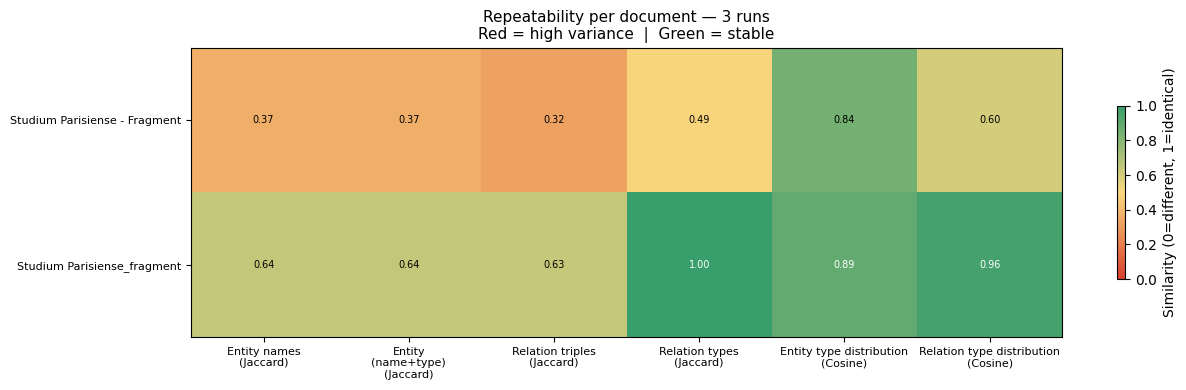

In [7]:
# ── Plot 1: per-document metric heatmap ───────────────────────────────────────
# Rows = documents, Columns = metrics
# Red = low similarity (problematic), Green = high similarity (stable)

heat_data = doc_df.set_index("record_id")[METRIC_COLS].values
doc_labels = doc_df["record_id"].astype(str).tolist()

cmap = LinearSegmentedColormap.from_list(
    "rg", [(0.85, 0.25, 0.18), (0.98, 0.85, 0.50), (0.22, 0.62, 0.42)]
)

fig, ax = plt.subplots(figsize=(13, max(4, len(doc_labels) * 0.5 + 1.5)))
im = ax.imshow(heat_data, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(
    [l.replace(" (", "\n(") for l in METRIC_LABELS],
    fontsize=8, ha="center"
)
ax.set_yticks(range(len(doc_labels)))
ax.set_yticklabels(doc_labels, fontsize=8)
ax.set_title(
    f"Repeatability per document — {N_RUNS} runs\n"
    "Red = high variance  |  Green = stable",
    fontsize=11
)

# Annotate each cell with the value
for i in range(len(doc_labels)):
    for j in range(len(METRIC_COLS)):
        v = heat_data[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=7, color="black" if 0.3 < v < 0.85 else "white")

plt.colorbar(im, ax=ax, label="Similarity (0=different, 1=identical)", shrink=0.6)
plt.tight_layout()
plt.savefig("repeatability_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

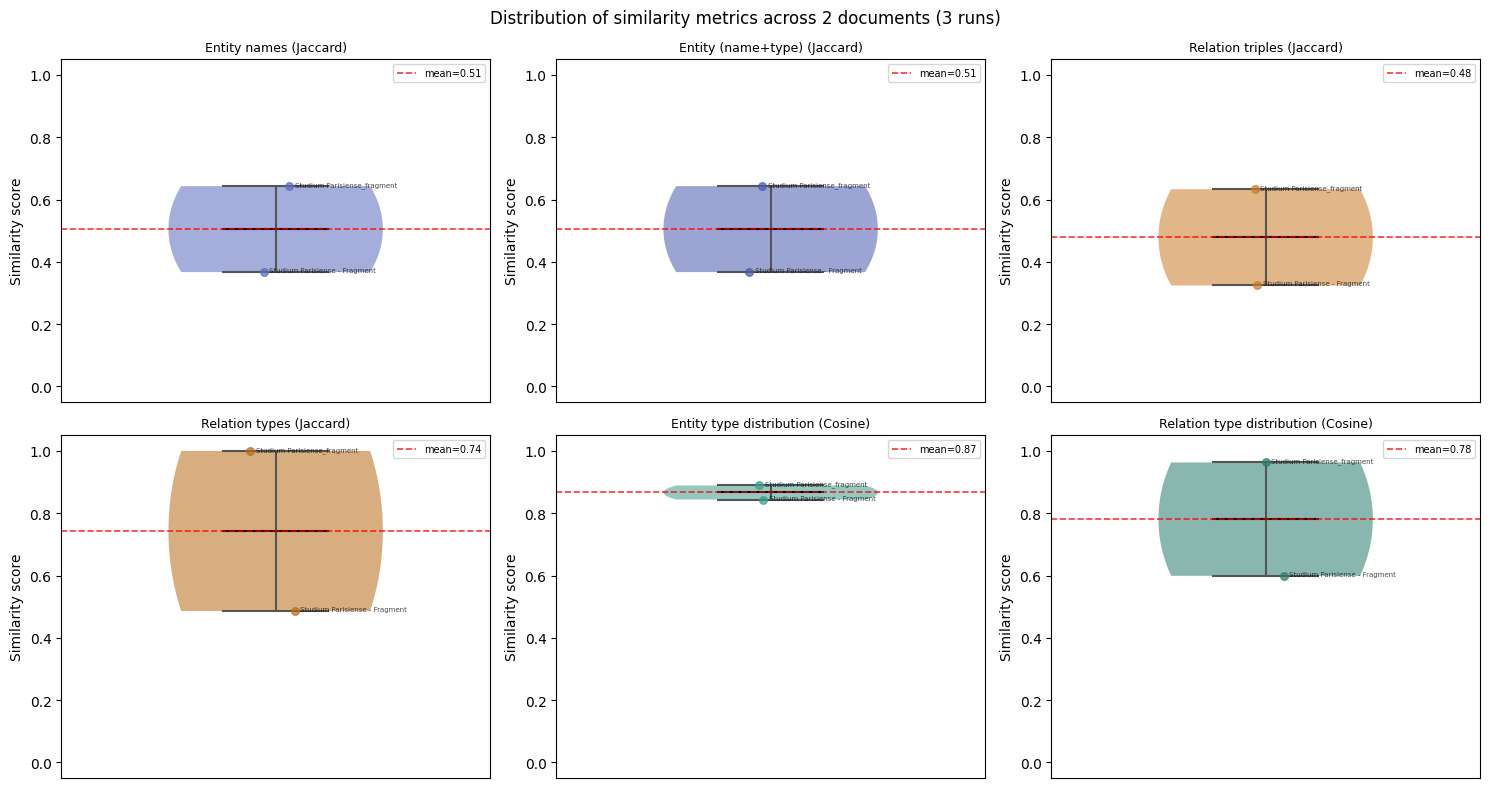

In [8]:
# ── Plot 2: metric distributions (violin + strip) ────────────────────────────
# Shows spread of each metric across all documents

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    f"Distribution of similarity metrics across {len(doc_df)} documents ({N_RUNS} runs)",
    fontsize=12
)
COLORS = ["#5b6abf", "#4a59ae", "#c97d2a", "#b86c19", "#3a9e8e", "#297d6d"]

for ax, col, label, color in zip(axes.flat, METRIC_COLS, METRIC_LABELS, COLORS):
    vals = doc_df[col].values
    # Violin
    parts = ax.violinplot(vals, positions=[0], showmedians=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.55)
    parts["cmedians"].set_color("black")
    parts["cmins"].set_color("#555")
    parts["cmaxes"].set_color("#555")
    parts["cbars"].set_color("#555")
    # Strip (individual dots)
    jitter = np.random.uniform(-0.06, 0.06, size=len(vals))
    ax.scatter(jitter, vals, alpha=0.7, s=30, color=color, zorder=3)
    # Labels on dots
    for x, y, rid in zip(jitter, vals, doc_df["record_id"]):
        ax.annotate(str(rid), (x, y), fontsize=5, alpha=0.7,
                    xytext=(4, 0), textcoords="offset points")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.5, 0.5)
    ax.set_xticks([])
    ax.set_ylabel("Similarity score")
    ax.set_title(label, fontsize=9)
    ax.axhline(vals.mean(), color="red", lw=1.2, ls="--", alpha=0.8,
               label=f"mean={vals.mean():.2f}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("repeatability_distributions.png", dpi=130, bbox_inches="tight")
plt.show()

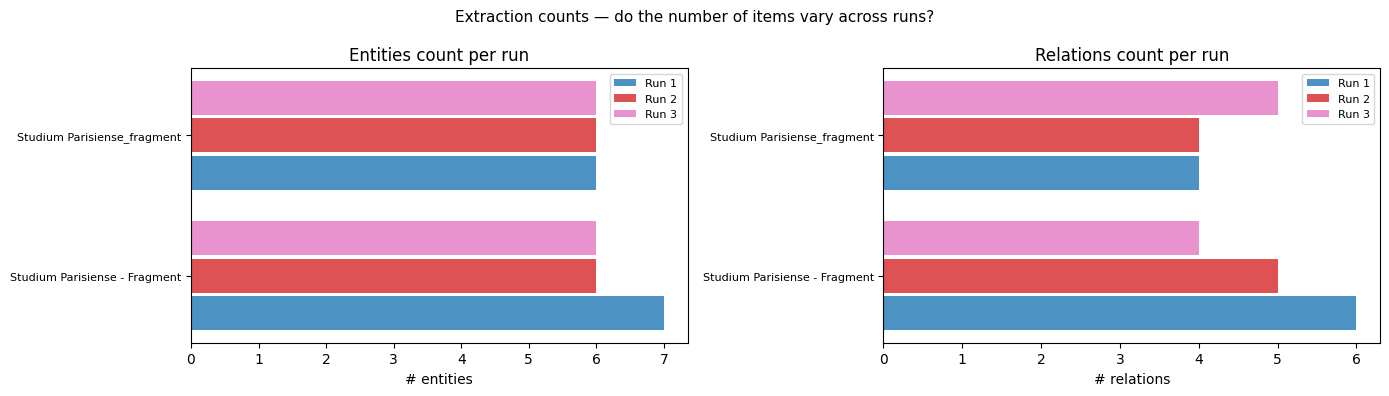

In [9]:
# ── Plot 3: entity and relation counts per run per document ───────────────────
# Shows whether the LLM extracts more/fewer elements across runs

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(common_ids) * 0.5 + 1)))
colors_runs = plt.cm.tab10(np.linspace(0, 0.6, N_RUNS))

for ax_idx, (kind, field) in enumerate([("entities", "entities"),
                                         ("relations", "relations")]):
    ax = axes[ax_idx]
    y_pos = np.arange(len(common_ids))
    bar_h = 0.8 / N_RUNS

    for run_i, run in enumerate(loaded_runs):
        counts = [
            len(run[kind].get(rid, {}).get(field, []))
            for rid in common_ids
        ]
        offset = (run_i - N_RUNS / 2 + 0.5) * bar_h
        ax.barh(
            y_pos + offset, counts, bar_h * 0.9,
            label=run["label"], color=colors_runs[run_i], alpha=0.8
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(common_ids, fontsize=8)
    ax.set_xlabel(f"# {kind}")
    ax.set_title(f"{kind.capitalize()} count per run")
    ax.legend(fontsize=8)

plt.suptitle("Extraction counts — do the number of items vary across runs?", fontsize=11)
plt.tight_layout()
plt.savefig("repeatability_counts.png", dpi=130, bbox_inches="tight")
plt.show()

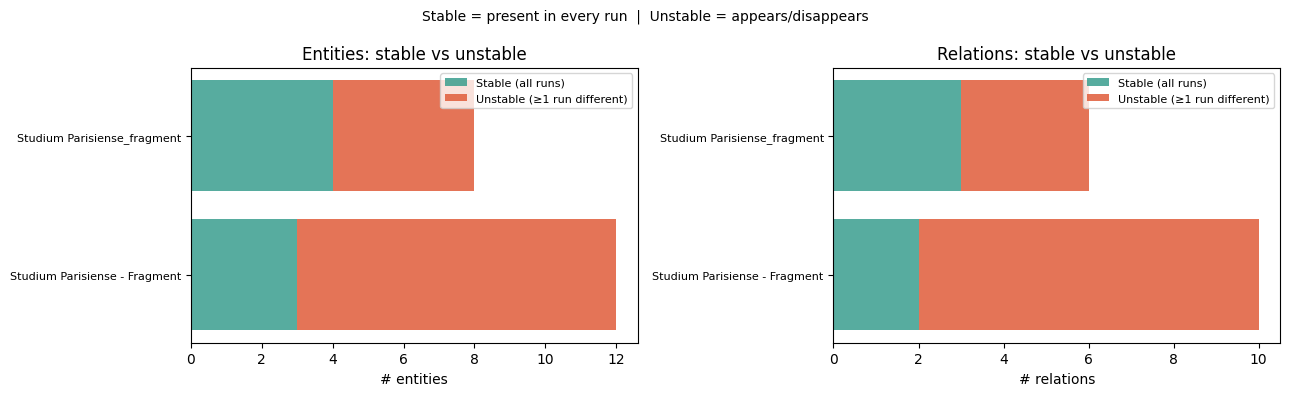

In [10]:
# ── Plot 4: stable vs unstable breakdown per document ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(common_ids) * 0.55 + 1)))

for ax, (stable_col, unstable_col, title) in zip(
    axes,
    [
        ("stable_ents",  "unstable_ents",  "Entities"),
        ("stable_rels",  "unstable_rels",  "Relations"),
    ]
):
    y   = np.arange(len(doc_df))
    ax.barh(y, doc_df[stable_col],   color="#3a9e8e", label="Stable (all runs)",  alpha=0.85)
    ax.barh(y, doc_df[unstable_col], left=doc_df[stable_col],
            color="#e05c3a", label="Unstable (≥1 run different)", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(doc_df["record_id"].astype(str), fontsize=8)
    ax.set_xlabel(f"# {title.lower()}")
    ax.set_title(f"{title}: stable vs unstable")
    ax.legend(fontsize=8)

plt.suptitle("Stable = present in every run  |  Unstable = appears/disappears",
             fontsize=10)
plt.tight_layout()
plt.savefig("repeatability_stable_unstable.png", dpi=130, bbox_inches="tight")
plt.show()

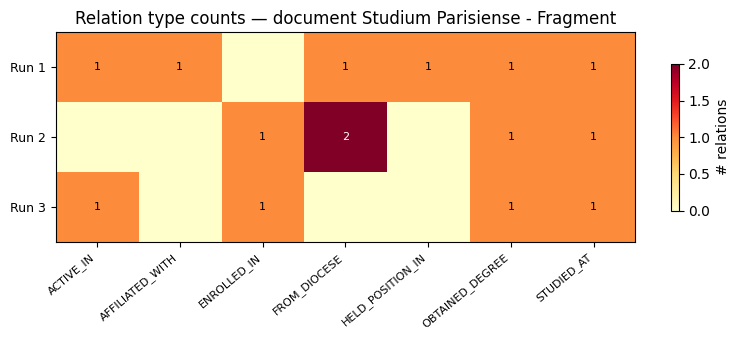

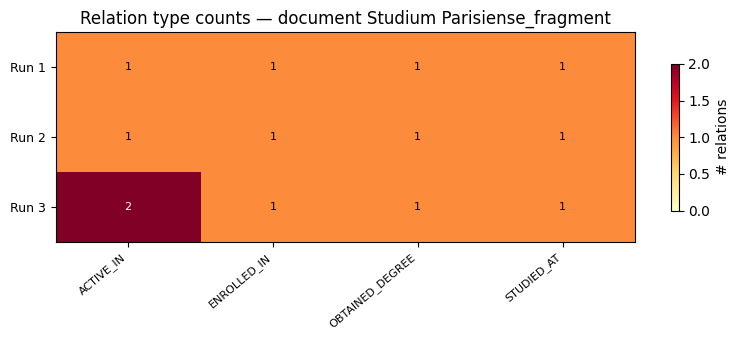

In [11]:
# ── Plot 5: relation type usage per run per document ─────────────────────────
# Shows which types the LLM uses consistently vs drops between runs

all_rel_types = sorted(CANONICAL_RELATIONS)

for rid in common_ids:
    # Build (N_RUNS × N_TYPES) matrix of relation type counts
    matrix = []
    for run in loaded_runs:
        rr = run["relations"].get(rid, {})
        d  = rel_type_dist(rr)
        matrix.append([d.get(rt, 0) for rt in all_rel_types])
    matrix = np.array(matrix, dtype=float)

    # Only show types that appear at least once across all runs
    used_mask = matrix.sum(axis=0) > 0
    if not used_mask.any():
        continue
    matrix_used = matrix[:, used_mask]
    types_used  = [t for t, u in zip(all_rel_types, used_mask) if u]

    fig, ax = plt.subplots(figsize=(max(8, len(types_used) * 0.55 + 1.5), 3.5))
    im = ax.imshow(matrix_used, cmap="YlOrRd", aspect="auto", vmin=0)
    ax.set_xticks(range(len(types_used)))
    ax.set_xticklabels(types_used, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(N_RUNS))
    ax.set_yticklabels([r["label"] for r in loaded_runs], fontsize=9)
    ax.set_title(f"Relation type counts — document {rid}")
    for i in range(N_RUNS):
        for j in range(len(types_used)):
            v = int(matrix_used[i, j])
            if v > 0:
                ax.text(j, i, str(v), ha="center", va="center",
                        fontsize=8, color="white" if v > matrix_used.max() * 0.6 else "black")
    plt.colorbar(im, ax=ax, label="# relations", shrink=0.7)
    plt.tight_layout()
    plt.savefig(f"rel_types_doc_{rid}.png", dpi=120, bbox_inches="tight")
    plt.show()

## 6 — Deep dive: what exactly is unstable?

In [12]:
# For each document: print stable/unstable entities and relations
# This is the qualitative complement to the plots above

for rid in common_ids:
    info = stability_info[rid]
    row  = doc_df[doc_df["record_id"] == rid].iloc[0]

    print(f"\n{'═'*60}")
    print(f" Document: {rid}")
    print(f" Entity Jaccard={row['j_ent_names']:.2f}  "
          f"Relation Jaccard={row['j_rel_triples']:.2f}")
    print(f"{'═'*60}")

    # ── Entities ──────────────────────────────────────────────────────────
    stable_e = sorted(info["stable_ents"])
    unstable_e = sorted(info["unstable_ents"])
    print(f"\n  ENTITIES  stable={len(stable_e)}  unstable={len(unstable_e)}")

    if stable_e:
        print("  Stable:")
        for e in stable_e:
            print(f"    ✓  {e}")

    if unstable_e:
        print("  Unstable (present in some runs only):")
        for e in unstable_e:
            # Show which runs had it
            in_runs = [
                run["label"]
                for run in loaded_runs
                if e in ent_name_set(run["entities"].get(rid, {}))
            ]
            print(f"    ✗  {e}  → found in: {', '.join(in_runs)}")

    # ── Relations ─────────────────────────────────────────────────────────
    stable_r   = sorted(info["stable_rels"])
    unstable_r = sorted(info["unstable_rels"])
    print(f"\n  RELATIONS  stable={len(stable_r)}  unstable={len(unstable_r)}")

    if stable_r:
        print("  Stable:")
        for src, rtype, tgt in stable_r:
            print(f"    ✓  {src}  --[{rtype}]-->  {tgt}")

    if unstable_r:
        print("  Unstable:")
        for src, rtype, tgt in unstable_r:
            in_runs = [
                run["label"]
                for i, run in enumerate(loaded_runs)
                if (src, rtype, tgt) in rel_triple_set(
                    run["entities"].get(rid, {}),
                    run["relations"].get(rid, {})
                )
            ]
            print(f"    ✗  {src}  --[{rtype}]-->  {tgt}  → found in: {', '.join(in_runs)}")

    # ── Off-enum ──────────────────────────────────────────────────────────
    all_off = []
    for run in loaded_runs:
        rr = run["relations"].get(rid, {})
        bad = off_enum(rr)
        if bad:
            all_off.append(f"  {run['label']}: {bad}")
    if all_off:
        print("\n  OFF-ENUM relation types:")
        for line in all_off:
            print(line)


════════════════════════════════════════════════════════════
 Document: Studium Parisiense - Fragment
 Entity Jaccard=0.37  Relation Jaccard=0.32
════════════════════════════════════════════════════════════

  ENTITIES  stable=3  unstable=9
  Stable:
    ✓  jean de murs
    ✓  maître ès arts
    ✓  université de paris
  Unstable (present in some runs only):
    ✗  1380  → found in: Run 1
    ✗  chanoine  → found in: Run 1
    ✗  crète  → found in: Run 3
    ✗  créteil  → found in: Run 2
    ✗  diocèse de sens  → found in: Run 2
    ✗  faculté des arts  → found in: Run 2, Run 3
    ✗  muris  → found in: Run 1
    ✗  médecin  → found in: Run 3
    ✗  notre-dame de paris  → found in: Run 1

  RELATIONS  stable=2  unstable=8
  Stable:
    ✓  jean de murs  --[OBTAINED_DEGREE]-->  maître ès arts
    ✓  jean de murs  --[STUDIED_AT]-->  université de paris
  Unstable:
    ✗  jean de murs  --[ACTIVE_IN]-->  1380  → found in: Run 1
    ✗  jean de murs  --[ACTIVE_IN]-->  crète  → found in: Run 3

## 7 — Save outputs

In [13]:
doc_df.to_csv("repeatability_per_document.csv", index=False)
pair_df.to_csv("repeatability_per_pair.csv", index=False)
summary_df.round(3).to_csv("repeatability_summary.csv")

print("Saved:")
print("  repeatability_per_document.csv  — one row per document, mean metrics")
print("  repeatability_per_pair.csv      — one row per (document, run_i, run_j)")
print("  repeatability_summary.csv       — global summary table")
print("  repeatability_heatmap.png")
print("  repeatability_distributions.png")
print("  repeatability_counts.png")
print("  repeatability_stable_unstable.png")
print("  rel_types_doc_<id>.png          — one per document")

Saved:
  repeatability_per_document.csv  — one row per document, mean metrics
  repeatability_per_pair.csv      — one row per (document, run_i, run_j)
  repeatability_summary.csv       — global summary table
  repeatability_heatmap.png
  repeatability_distributions.png
  repeatability_counts.png
  repeatability_stable_unstable.png
  rel_types_doc_<id>.png          — one per document
